**Proyecto Grupo #1**

**Integrantes:**

Orlin Salgado

Alvin Núñez

Marlon Chinchilla

Allison Chavez

Kristhian Benitez


#**Fase 1**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('mushroom.csv')

###dimensiones del dataset

In [ ]:
df.shape

(61069, 21)

In [ ]:
df.head(10)

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w
5,p,15.34,x,g,o,f,e,NaN,w,17.84,...,s,y,w,u,w,t,p,NaN,d,u
6,p,14.85,f,h,o,f,e,NaN,w,17.71,...,s,y,w,u,w,t,g,NaN,d,w
7,p,14.86,x,h,e,f,e,NaN,w,17.03,...,s,y,w,u,w,t,p,NaN,d,u
8,p,12.85,f,g,o,f,e,NaN,w,17.27,...,s,y,w,u,w,t,p,NaN,d,a
9,p,13.55,f,g,e,f,e,NaN,w,16.04,...,s,y,w,u,w,t,p,NaN,d,w


###Tipos de Datos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-surface           46949 non-null  object 
 4   cap-color             61069 non-null  object 
 5   does-bruise-or-bleed  61069 non-null  object 
 6   gill-attachment       51185 non-null  object 
 7   gill-spacing          36006 non-null  object 
 8   gill-color            61069 non-null  object 
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-root             9531 non-null   object 
 12  stem-surface          22945 non-null  object 
 13  stem-color            61069 non-null  object 
 14  veil-type             3177 non-null   object 
 15  veil-color         

In [ ]:
df.describe()

,cap-diameter,stem-height,stem-width
count,61069.000000,61069.000000,61069.000000
mean,6.733854,6.581538,12.149410
std,5.264845,3.370017,10.035955
min,0.380000,0.000000,0.000000
25%,3.480000,4.640000,5.210000
50%,5.860000,5.950000,10.190000
75%,8.540000,7.740000,16.570000
max,62.340000,33.920000,103.910000


###Diccionario de datos se encuentra en el informe

###Distribución de la clase

In [ ]:
df['class'].value_counts()

,count
class,
p,33888
e,27181


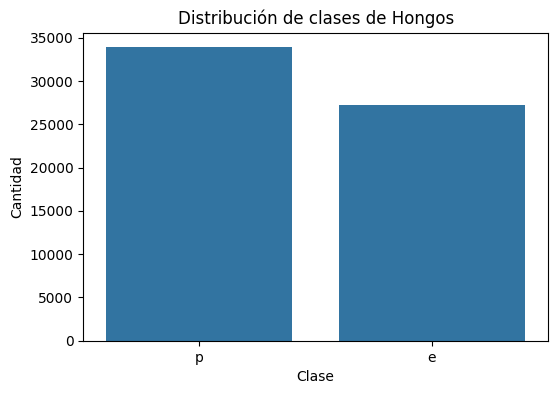

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='class')

plt.title("Distribución de clases de Hongos")
plt.xlabel("Clase")
plt.ylabel("Cantidad")

plt.show()

**¿esta balanceado?**

segun los datos y el grafico hay mas catidad de la clasificacion **p** que son los hongos venenosos, con una diferencia de 6,707 que es casi el 11%. Aun asi no es un desbalance tan desproporcionado, asi que se consideró aceptable.

###Cardinalidad de cada atributo

In [ ]:
#cardinalidad (categorias por atributo)
df.nunique()

,0
class,2
cap-diameter,2571
cap-shape,7
cap-surface,11
cap-color,12
does-bruise-or-bleed,2
gill-attachment,7
gill-spacing,3
gill-color,12
stem-height,2226


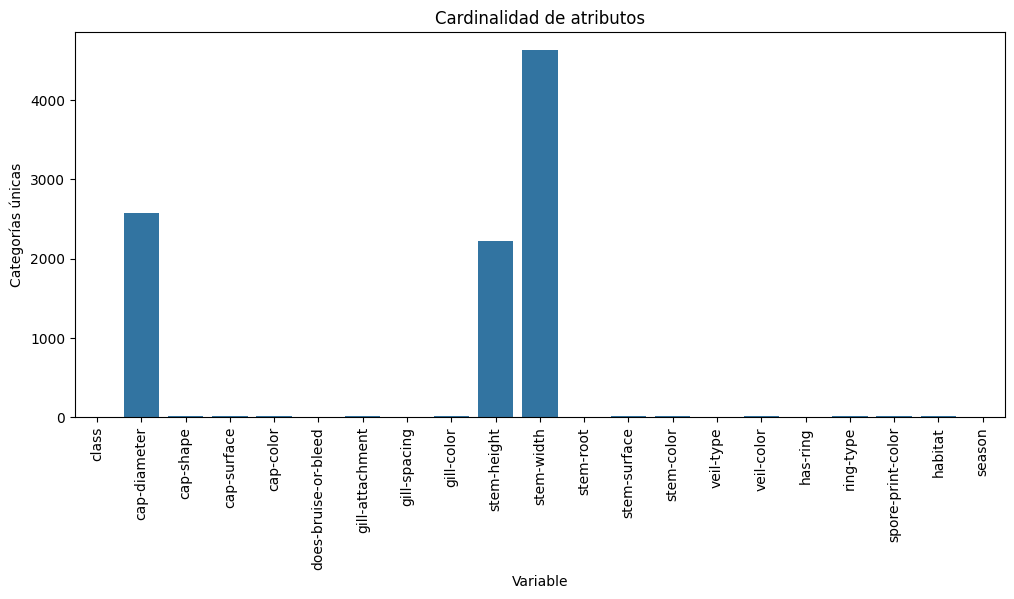

In [ ]:
cardinalidad = pd.DataFrame({
    'Variable': df.columns,
    'Categorías únicas': df.nunique(),
    'Valores faltantes': df.isnull().sum()
})
plt.figure(figsize=(12,5))
sns.barplot(data=cardinalidad,x='Variable', y='Categorías únicas')
plt.xticks(rotation=90)
plt.title("Cardinalidad de atributos")
plt.show()

como se observa en la grafica los atributos con mas categorias son: stem-width siendo el mayor con 4630, le siguen cap-diameter (2571) y stem-height (2226). Esto tiene sentido ya que corresponden a los atributos numericos, los cuales tienen una gran cantidad de posibilidades.

###Valores Faltantes

In [ ]:
#valores faltantes
df.isnull().sum()

,0
class,0
cap-diameter,0
cap-shape,0
cap-surface,14120
cap-color,0
does-bruise-or-bleed,0
gill-attachment,9884
gill-spacing,25063
gill-color,0
stem-height,0


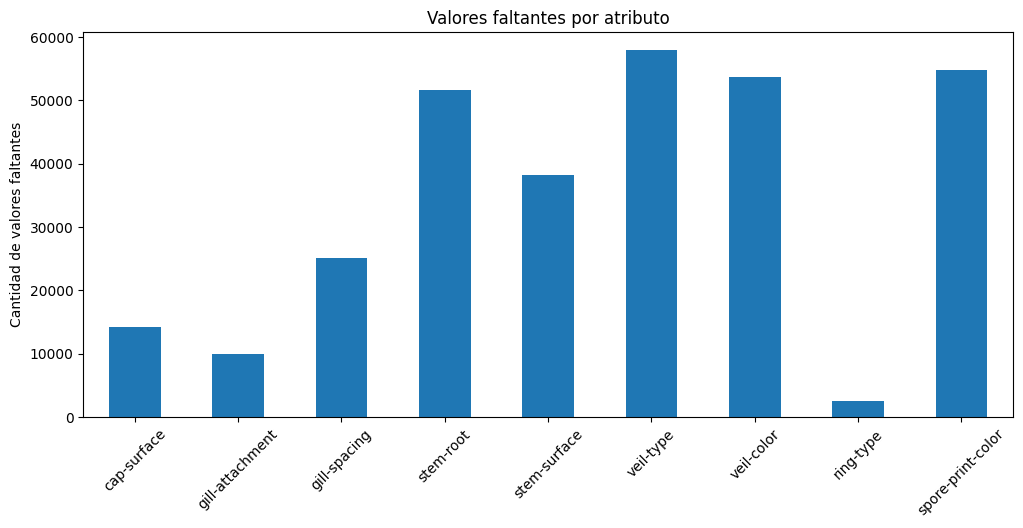

In [ ]:
faltantes = df.isnull().sum()
faltantes[faltantes>0]

#grafica de valores faltantes
plt.figure(figsize=(12,5))
faltantes[faltantes>0].plot(kind='bar')
plt.title("Valores faltantes por atributo")
plt.ylabel("Cantidad de valores faltantes")

plt.xticks(rotation=45)
plt.show()

En la grafica se puede apreciar mas a detalle que las columnas con mas valores faltantes son veil-type, spore-print-color, veil-color, stem-root y stem-surface. no se eliminarán, ya que estas variables podrían contener información relevante para la clasificación de los hongos y su ausencia puede representar una característica propia del ejemplar, más que un error en la recolección de los datos

Para las otras columnas con un número moderado de valores faltantes, como cap-surface, gill-attachment y gill-spacing, lo mejor es llenar los valores faltantes con la moda de cada columna.

In [ ]:
#probando si alguna columna usa el "?" para valores desconocidos
(df == "?").sum()

,0
class,0
cap-diameter,0
cap-shape,0
cap-surface,0
cap-color,0
does-bruise-or-bleed,0
gill-attachment,0
gill-spacing,0
gill-color,0
stem-height,0


No hay columnas que usen el "?" como valor desconocido asi que se seguira trabajando solo con los valores nulos evaluados antes.

##Análisis de correlación

In [ ]:
#como hay muchas variables categóricas, primero se va a convertir las categorías usando Label Encoding
from sklearn.preprocessing import LabelEncoder

df_corr = df.copy()

encoder = LabelEncoder()

for col in df_corr.columns:
    df_corr[col] = encoder.fit_transform(
        df_corr[col].astype(str)
    )


correlacion = df_corr.corr()

cor_clase = correlacion['class'].sort_values(
    ascending=False
)

cor_clase

,class
class,1.000000
ring-type,0.066880
stem-root,0.062233
has-ring,0.057559
veil-type,0.052677
stem-width,0.044351
cap-color,0.026411
gill-spacing,-0.004267
does-bruise-or-bleed,-0.019889
cap-surface,-0.025475


In [ ]:
#seleccion de 5 atributos y la clase
cor_clase.head(6)



,class
class,1.000000
ring-type,0.066880
stem-root,0.062233
has-ring,0.057559
veil-type,0.052677
stem-width,0.044351


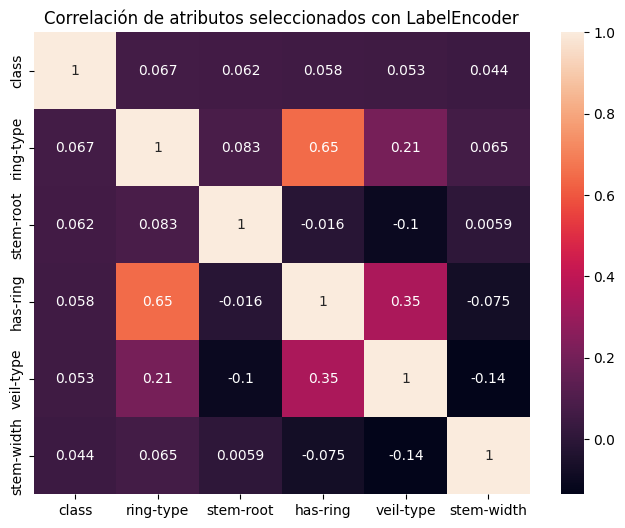

In [ ]:
selected_attributes = ['class', 'ring-type', 'stem-root', 'has-ring', 'veil-type', 'stem-width']
df_selected = df_corr[selected_attributes]

plt.figure(figsize=(8, 6))
sns.heatmap(df_selected.corr(), annot=True)
plt.title('Correlación de atributos seleccionados con LabelEncoder')
plt.show()

El análisis de correlación muestra que ninguno de los 5 atributos seleccionados posee una relación lineal fuerte con la variable class, ya que todos presentan coeficientes inferiores a 0.10. lo que nos quiere decir que la clasificación de los hongos no depende de una única característica, sino de la combinación de múltiples atributos. por otra parte, la correlación entre ring-type y has-ring es la mas alta con 0.65, lo cual segun se investigó es lógico, ya que solamente puede existir un tipo de anillo cuando el hongo posee uno. otras correlacion moderada seria la de  has-ring y veil-type con 0.35.

In [ ]:
#para un mejor anaisis se probará usando Cramér's V, debido a que es mas adecuado para variables categóricas
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):

    tabla = pd.crosstab(x, y)

    chi2 = chi2_contingency(tabla)[0]

    n = tabla.sum().sum()

    r, k = tabla.shape

    return np.sqrt(chi2 / (n * (min(r-1, k-1))))

In [ ]:
resultado = []

for columna in df.columns:

    if columna != "class":

        valor = cramers_v(df[columna].fillna("Desconocido"), df["class"])

        resultado.append([columna, valor])

resultado = pd.DataFrame(resultado, columns=["Atributo", "CramersV"])
resultado = resultado.sort_values(by="CramersV", ascending=False)
resultado

,Atributo,CramersV
9,stem-width,0.417403
8,stem-height,0.317092
0,cap-diameter,0.308390
12,stem-color,0.273194
11,stem-surface,0.257382
3,cap-color,0.240801
10,stem-root,0.229610
2,cap-surface,0.228485
5,gill-attachment,0.225098
16,ring-type,0.204670


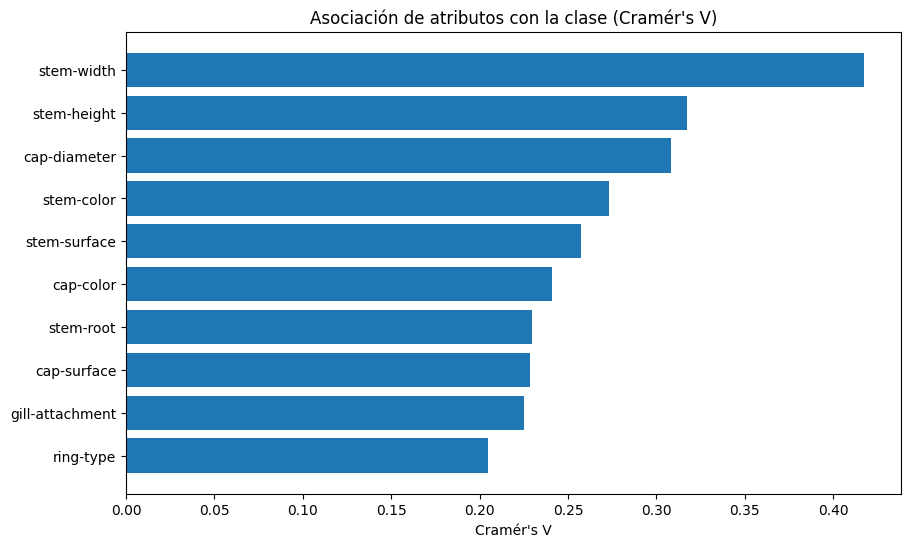

In [ ]:
#grafico de resultados del analisis de correlacion con la clase usando Cramér's V
top = resultado.head(10)
plt.figure(figsize=(10,6))
plt.barh(
    top["Atributo"],
    top["CramersV"]
)
plt.title("Asociación de atributos con la clase (Cramér's V)")
plt.xlabel("Cramér's V")

plt.gca().invert_yaxis()

plt.show()

el grafico muestra una mejor correlacion entre atributos y la clase usando Cramér's V, los resultados dan una asociación mas moderada, pero aun no llegan a una asociación fuerte. con atributos como stem-width,stem-height y cap-diameter que estan entre 0.30 y 0.50 correspondiente a la asociación moderada. Precisamente estas variables son las unicas numericas, lo que indica que las medidas físicas del hongo contienen más información predictiva que muchas de las variables categóricas.

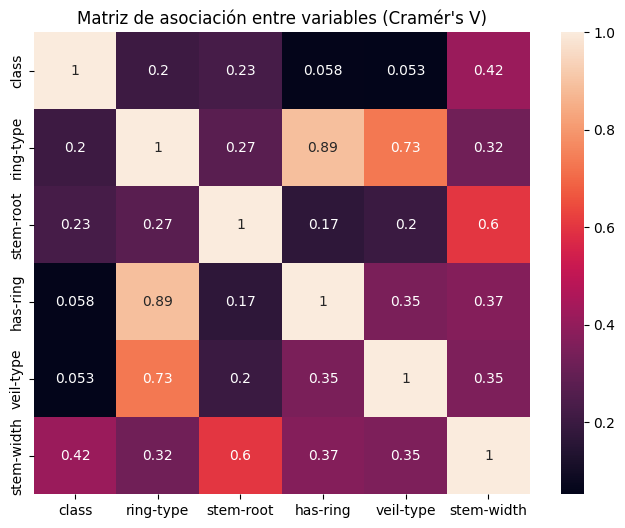

In [ ]:
#haciendo un analisis de correlacion para comparar los atributos seleccionados con LabelEncoder pero ahora con Cramér's V

variables = ['class', 'ring-type', 'stem-root', 'has-ring', 'veil-type', 'stem-width']
matriz = pd.DataFrame(index=variables, columns=variables)

for v1 in variables:
    for v2 in variables:
        matriz.loc[v1, v2] = cramers_v(
            df[v1].fillna("Desconocido"),
            df[v2].fillna("Desconocido")
        )

matriz = matriz.astype(float)
plt.figure(figsize=(8,6))
sns.heatmap(matriz,annot=True,)

plt.title("Matriz de asociación entre variables (Cramér's V)")
plt.show()

 como se observa la correlación entre ring-type y has-ring sigue siendo la mas altas y ahora con una Asociación mas fuerte que el analisis anterior, ahora tambien muestra otras Asociaciones fuertes como la de ring-type y veil-type, steem-root y stem-witdth

#**Fase 2**


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

2.1A Verificación y eliminación justificada de columnas sin información

In [ ]:
#Verificar columnas sin información
unicos = df.nunique()
columnas_constantes = unicos[unicos <= 1].index.tolist()

print(f"Columnas con un único valor (constantes): {columnas_constantes}")

Columnas con un único valor (constantes): ['veil-type']


2.1B Eliminamos las columnas constantes si existen en el DataFrame para evitar ruido en los modelos

In [ ]:
df_clean = df.drop(columns=columnas_constantes)

Se identifico una  columna con un único valor en todos los registros. esta variable no aportan información que sirva de para identifificar el tipo de hongo, porque no tiene ninguna varianza . Se decidio eliminarlas antes del entrenamiento de los modelos.

2.2 Separación de la variable objetivo (y) y las características (X)

In [ ]:
#Separar X e y
X = df_clean.drop(columns=['class'])
y = df_clean['class']

2.3 División estratificada en entrenamiento (70%), validación (15%) y prueba (15%)

In [ ]:
#División estratificada
#división 70-30
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

In [ ]:
#División del 30% en dos partes iguales
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print(f"Dimensiones del conjunto de entrenamiento: {X_train.shape}")
print(f"Dimensiones del conjunto de validación:    {X_val.shape}")
print(f"Dimensiones del conjunto de prueba:        {X_test.shape}")

Dimensiones del conjunto de entrenamiento: (42748, 19)
Dimensiones del conjunto de validación:    (9160, 19)
Dimensiones del conjunto de prueba:        (9161, 19)


In [ ]:
#verificaciñon que la distribución de clase se mantine
print(y_train.value_counts(normalize=True))

print(y_val.value_counts(normalize=True))

print(y_test.value_counts(normalize=True))

class
p    0.554903
e    0.445097
Name: proportion, dtype: float64
class
p    0.554913
e    0.445087
Name: proportion, dtype: float64
class
p    0.554961
e    0.445039
Name: proportion, dtype: float64


2.4 Vectorización y Escalado (Preparación para kNN, SVM, Redes Neuronales)

In [ ]:
#Identificación de columnas categoricas y numericas
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nVariables categóricas a vectorizar: {len(categorical_cols)}")
print(f"Variables numéricas a escalar: {len(numerical_cols)}")


Variables categóricas a vectorizar: 16
Variables numéricas a escalar: 3


In [ ]:
#Pipeline para variables categóricas
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant',
                              fill_value='Desconocido')),
    ('encoder', OneHotEncoder(handle_unknown='ignore',
                              sparse_output=False))
])

Como las variables categoricas representan categorias nominales sin un orden natural, se uso el One-Hot Encoding para codificarlas. Esto para evita introducir relaciones numéricas artificiales entre categorías. se rellena los valores faltantes con "desconocido"

In [ ]:
#Pipeline para variables numéricas
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

para variables numericas se usara la mediana para valores faltantes

In [ ]:
#Creacion del transformador
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_cols),
        ('num', numerical_transformer, numerical_cols)
    ]
)

2.5 Creación del Pipeline para evitar Fuga de Datos

In [ ]:
#construiremos un Pipeline para usarlo únicamente donde sea necesario
pipeline_preprocesamiento = Pipeline(steps=[
    ('preprocesador', preprocessor)
])

X_train_transformed = pipeline_preprocesamiento.fit_transform(X_train)

X_val_transformed = pipeline_preprocesamiento.transform(X_val)
X_test_transformed = pipeline_preprocesamiento.transform(X_test)

print("\n¡Transformación completada con éxito!")
print(f"Forma de X_train después de la vectorización/escalado: {X_train_transformed.shape}")
print(f"Forma de X_val después de la vectorización/escalado:   {X_val_transformed.shape}")
print(f"Forma de X_test después de la vectorización/escalado:  {X_test_transformed.shape}")


¡Transformación completada con éxito!
Forma de X_train después de la vectorización/escalado: (42748, 126)
Forma de X_val después de la vectorización/escalado:   (9160, 126)
Forma de X_test después de la vectorización/escalado:  (9161, 126)


#**Fase 3**


##**Fase 3 — Entrenamiento supervisado**

En esta fase se entrenan cuatro algoritmos vistos en clase:

1. Regresión logística  
2. K vecinos más cercanos (kNN)  
3. Árbol de decisión  
4. Random Forest  

Cada modelo se prueba con diferentes hiperparámetros y se evalúa usando el conjunto de validación.  
El conjunto de prueba se reserva para la Fase 5.

In [ ]:
# Importación de los modelos
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Importación de las métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Herramientas para el reto del atributo clave
from sklearn.inspection import permutation_importance
from sklearn.base import clone


###**Función para evaluar los modelos**

La función calcula las métricas solicitadas y muestra la matriz de confusión.  
Para precision, recall y F1 se toma como clase positiva a `p`, que representa los hongos venenosos.

In [ ]:
# Lista donde se guardarán los resultados
resultados = []

def evaluar_modelo(nombre, modelo, X_validacion, y_validacion):
    # Realizar las predicciones
    y_pred = modelo.predict(X_validacion)

    # Calcular las métricas
    accuracy = accuracy_score(y_validacion, y_pred)
    precision = precision_score(
        y_validacion,
        y_pred,
        pos_label='p',
        zero_division=0
    )
    recall = recall_score(
        y_validacion,
        y_pred,
        pos_label='p',
        zero_division=0
    )
    f1 = f1_score(
        y_validacion,
        y_pred,
        pos_label='p',
        zero_division=0
    )

    # Guardar los resultados
    resultados.append({
        'Modelo': nombre,
        'Accuracy': accuracy,
        'Precision venenoso': precision,
        'Recall venenoso': recall,
        'F1 venenoso': f1
    })

    # Mostrar las métricas
    print(f"\nResultados de {nombre}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")

    print("\nReporte de clasificación:")
    print(classification_report(y_validacion, y_pred, zero_division=0))

    # Crear la matriz de confusión
    matriz = confusion_matrix(
        y_validacion,
        y_pred,
        labels=['e', 'p']
    )

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        matriz,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Comestible', 'Venenoso'],
        yticklabels=['Comestible', 'Venenoso']
    )
    plt.title(f"Matriz de confusión - {nombre}")
    plt.xlabel("Predicción")
    plt.ylabel("Valor real")
    plt.show()

    return y_pred


####**3.1 Regresión logística**

Se prueban dos valores de `C`. Este hiperparámetro controla la regularización del modelo.

In [ ]:
# Primer modelo de regresión logística
logistica_1 = LogisticRegression(
    C=1,
    max_iter=2000,
    random_state=42
)

logistica_1.fit(X_train_transformed, y_train)

pred_logistica_1 = logistica_1.predict(X_val_transformed)

f1_logistica_1 = f1_score(
    y_val,
    pred_logistica_1,
    pos_label='p'
)

# Segundo modelo de regresión logística
logistica_2 = LogisticRegression(
    C=10,
    max_iter=2000,
    random_state=42
)

logistica_2.fit(X_train_transformed, y_train)

pred_logistica_2 = logistica_2.predict(X_val_transformed)

f1_logistica_2 = f1_score(
    y_val,
    pred_logistica_2,
    pos_label='p'
)

print(f"F1 con C=1:  {f1_logistica_1:.4f}")
print(f"F1 con C=10: {f1_logistica_2:.4f}")

# Seleccionar la mejor configuración
if f1_logistica_1 >= f1_logistica_2:
    mejor_logistica = logistica_1
    print("Se seleccionó C=1")
else:
    mejor_logistica = logistica_2
    print("Se seleccionó C=10")


F1 con C=1:  0.8744
F1 con C=10: 0.8714
Se seleccionó C=1



Resultados de Regresión logística
Accuracy: 0.8610
Precision: 0.8772
Recall: 0.8715
F1: 0.8744

Reporte de clasificación:
              precision    recall  f1-score   support

           e       0.84      0.85      0.84      4077
           p       0.88      0.87      0.87      5083

    accuracy                           0.86      9160
   macro avg       0.86      0.86      0.86      9160
weighted avg       0.86      0.86      0.86      9160



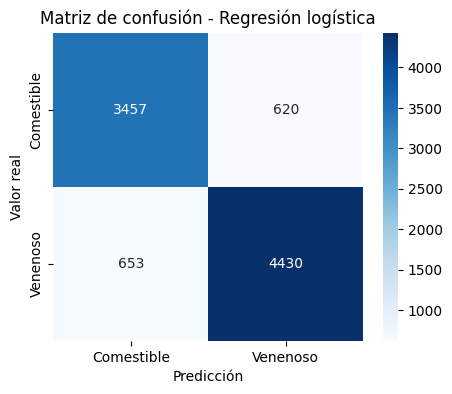

array(['p', 'p', 'e', ..., 'e', 'p', 'p'], dtype=object)

In [ ]:
# Evaluar la mejor regresión logística
evaluar_modelo(
    "Regresión logística",
    mejor_logistica,
    X_val_transformed,
    y_val
)


####**3.2 K vecinos más cercanos (kNN)**

Se prueban diferentes valores de `k` y dos formas de asignar el voto de los vecinos.


In [ ]:
# Configuraciones que se probarán para kNN
configuraciones_knn = [
    {'n_neighbors': 3, 'weights': 'uniform'},
    {'n_neighbors': 5, 'weights': 'uniform'},
    {'n_neighbors': 5, 'weights': 'distance'},
    {'n_neighbors': 9, 'weights': 'distance'}
]

mejor_f1_knn = -1
mejor_knn = None
mejor_configuracion_knn = None

for configuracion in configuraciones_knn:
    # Crear el modelo con la configuración actual
    modelo_knn = KNeighborsClassifier(
        n_neighbors=configuracion['n_neighbors'],
        weights=configuracion['weights']
    )

    # Entrenar y predecir
    modelo_knn.fit(X_train_transformed, y_train)
    pred_knn = modelo_knn.predict(X_val_transformed)

    # Calcular el F1 de la clase venenosa
    f1_actual = f1_score(
        y_val,
        pred_knn,
        pos_label='p'
    )

    print(
        f"k={configuracion['n_neighbors']}, "
        f"weights={configuracion['weights']}, "
        f"F1={f1_actual:.4f}"
    )

    # Guardar la mejor configuración
    if f1_actual > mejor_f1_knn:
        mejor_f1_knn = f1_actual
        mejor_knn = modelo_knn
        mejor_configuracion_knn = configuracion

print("\nMejor configuración de kNN:")
print(mejor_configuracion_knn)


k=3, weights=uniform, F1=1.0000
k=5, weights=uniform, F1=1.0000
k=5, weights=distance, F1=1.0000
k=9, weights=distance, F1=1.0000

Mejor configuración de kNN:
{'n_neighbors': 3, 'weights': 'uniform'}



Resultados de kNN
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1: 1.0000

Reporte de clasificación:
              precision    recall  f1-score   support

           e       1.00      1.00      1.00      4077
           p       1.00      1.00      1.00      5083

    accuracy                           1.00      9160
   macro avg       1.00      1.00      1.00      9160
weighted avg       1.00      1.00      1.00      9160



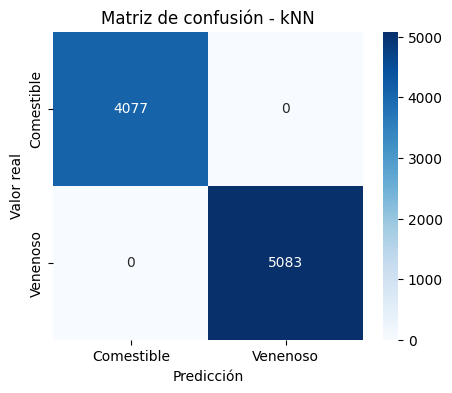

array(['p', 'p', 'p', ..., 'e', 'p', 'e'], dtype=object)

In [ ]:
# Evaluar el mejor modelo kNN
evaluar_modelo(
    "kNN",
    mejor_knn,
    X_val_transformed,
    y_val
)

####**3.3 Árbol de decisión**

Se prueban diferentes profundidades y cantidades mínimas de registros para dividir un nodo.


In [ ]:
# Configuraciones que se probarán para el árbol
configuraciones_arbol = [
    {'max_depth': 5, 'min_samples_split': 2},
    {'max_depth': 10, 'min_samples_split': 2},
    {'max_depth': 15, 'min_samples_split': 5},
    {'max_depth': None, 'min_samples_split': 5}
]

mejor_f1_arbol = -1
mejor_arbol = None
mejor_configuracion_arbol = None

for configuracion in configuraciones_arbol:
    # Crear el árbol con la configuración actual
    modelo_arbol = DecisionTreeClassifier(
        max_depth=configuracion['max_depth'],
        min_samples_split=configuracion['min_samples_split'],
        random_state=42
    )

    # Entrenar y predecir
    modelo_arbol.fit(X_train_transformed, y_train)
    pred_arbol = modelo_arbol.predict(X_val_transformed)

    # Calcular el F1 de la clase venenosa
    f1_actual = f1_score(
        y_val,
        pred_arbol,
        pos_label='p'
    )

    print(
        f"max_depth={configuracion['max_depth']}, "
        f"min_samples_split={configuracion['min_samples_split']}, "
        f"F1={f1_actual:.4f}"
    )

    # Guardar la mejor configuración
    if f1_actual > mejor_f1_arbol:
        mejor_f1_arbol = f1_actual
        mejor_arbol = modelo_arbol
        mejor_configuracion_arbol = configuracion

print("\nMejor configuración del árbol:")
print(mejor_configuracion_arbol)


max_depth=5, min_samples_split=2, F1=0.7062
max_depth=10, min_samples_split=2, F1=0.8506
max_depth=15, min_samples_split=5, F1=0.9555
max_depth=None, min_samples_split=5, F1=0.9988

Mejor configuración del árbol:
{'max_depth': None, 'min_samples_split': 5}



Resultados de Árbol de decisión
Accuracy: 0.9987
Precision: 0.9988
Recall: 0.9988
F1: 0.9988

Reporte de clasificación:
              precision    recall  f1-score   support

           e       1.00      1.00      1.00      4077
           p       1.00      1.00      1.00      5083

    accuracy                           1.00      9160
   macro avg       1.00      1.00      1.00      9160
weighted avg       1.00      1.00      1.00      9160



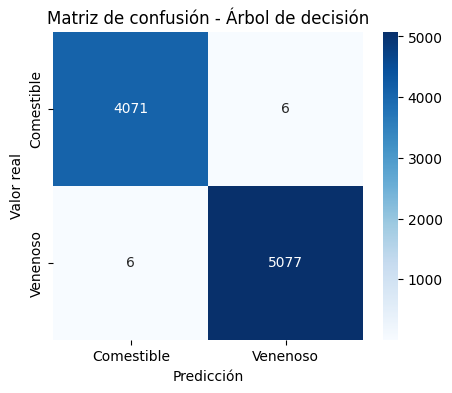

array(['p', 'p', 'p', ..., 'e', 'p', 'e'], dtype=object)

In [ ]:
# Evaluar el mejor árbol de decisión
evaluar_modelo(
    "Árbol de decisión",
    mejor_arbol,
    X_val_transformed,
    y_val
)


####**3.4 Random Forest**

Se prueban distintas cantidades de árboles y profundidades máximas.

In [ ]:
# Configuraciones que se probarán para Random Forest
configuraciones_random = [
    {'n_estimators': 100, 'max_depth': 10},
    {'n_estimators': 100, 'max_depth': None},
    {'n_estimators': 200, 'max_depth': 10},
    {'n_estimators': 200, 'max_depth': None}
]

mejor_f1_random = -1
mejor_random = None
mejor_configuracion_random = None

for configuracion in configuraciones_random:
    # Crear el modelo con la configuración actual
    modelo_random = RandomForestClassifier(
        n_estimators=configuracion['n_estimators'],
        max_depth=configuracion['max_depth'],
        random_state=42,
        n_jobs=-1
    )

    # Entrenar y predecir
    modelo_random.fit(X_train_transformed, y_train)
    pred_random = modelo_random.predict(X_val_transformed)

    # Calcular el F1 de la clase venenosa
    f1_actual = f1_score(
        y_val,
        pred_random,
        pos_label='p'
    )

    print(
        f"n_estimators={configuracion['n_estimators']}, "
        f"max_depth={configuracion['max_depth']}, "
        f"F1={f1_actual:.4f}"
    )

    # Guardar la mejor configuración
    if f1_actual > mejor_f1_random:
        mejor_f1_random = f1_actual
        mejor_random = modelo_random
        mejor_configuracion_random = configuracion

print("\nMejor configuración de Random Forest:")
print(mejor_configuracion_random)


n_estimators=100, max_depth=10, F1=0.9792
n_estimators=100, max_depth=None, F1=1.0000
n_estimators=200, max_depth=10, F1=0.9823
n_estimators=200, max_depth=None, F1=1.0000

Mejor configuración de Random Forest:
{'n_estimators': 100, 'max_depth': None}



Resultados de Random Forest
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1: 1.0000

Reporte de clasificación:
              precision    recall  f1-score   support

           e       1.00      1.00      1.00      4077
           p       1.00      1.00      1.00      5083

    accuracy                           1.00      9160
   macro avg       1.00      1.00      1.00      9160
weighted avg       1.00      1.00      1.00      9160



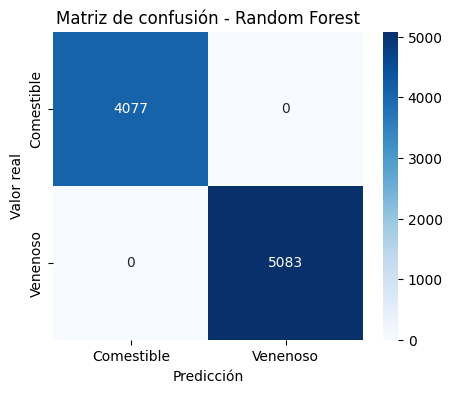

array(['p', 'p', 'p', ..., 'e', 'p', 'e'], dtype=object)

In [ ]:
# Evaluar el mejor Random Forest
evaluar_modelo(
    "Random Forest",
    mejor_random,
    X_val_transformed,
    y_val
)

####**3.5 Comparación de los modelos**

Los cuatro modelos se comparan usando las métricas obtenidas en validación.  
Se selecciona como mejor modelo el que tenga el F1 más alto para la clase venenosa

In [ ]:
# Crear la tabla comparativa
tabla_resultados = pd.DataFrame(resultados)

# Ordenar por el F1 de la clase venenosa
tabla_resultados = tabla_resultados.sort_values(
    by='F1 venenoso',
    ascending=False
).reset_index(drop=True)

display(tabla_resultados.round(4))


,Modelo,Accuracy,Precision venenoso,Recall venenoso,F1 venenoso
0,kNN,1.0000,1.0000,1.0000,1.0000
1,Random Forest,1.0000,1.0000,1.0000,1.0000
2,Árbol de decisión,0.9987,0.9988,0.9988,0.9988
3,Regresión logística,0.8610,0.8772,0.8715,0.8744


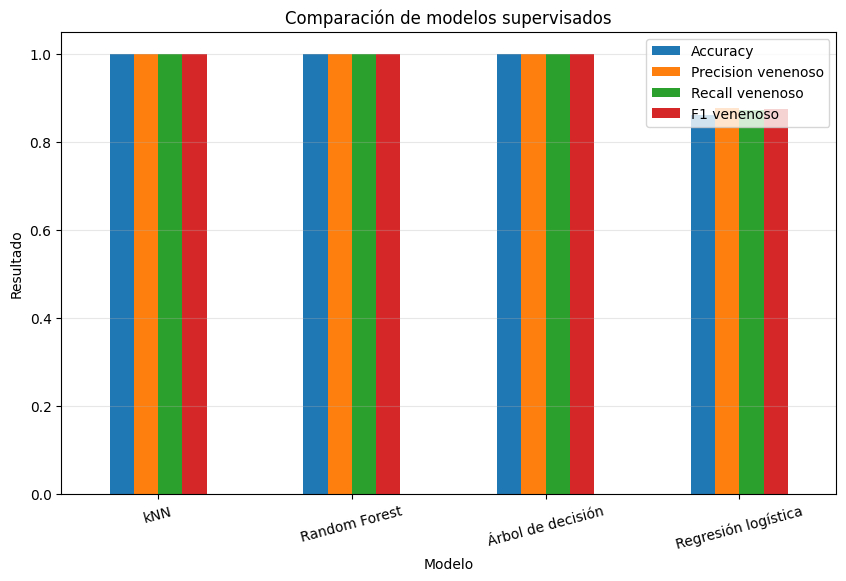

In [ ]:
# Gráfica comparativa de las métricas
tabla_grafica = tabla_resultados.set_index('Modelo')[
    ['Accuracy', 'Precision venenoso', 'Recall venenoso', 'F1 venenoso']
]

tabla_grafica.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("Comparación de modelos supervisados")
plt.ylabel("Resultado")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.show()


In [ ]:
# Guardar los modelos en un diccionario
modelos = {
    'Regresión logística': mejor_logistica,
    'kNN': mejor_knn,
    'Árbol de decisión': mejor_arbol,
    'Random Forest': mejor_random
}

# Seleccionar el mejor modelo según el F1
nombre_mejor_modelo = tabla_resultados.loc[0, 'Modelo']
mejor_modelo = modelos[nombre_mejor_modelo]

print(f"El mejor modelo es: {nombre_mejor_modelo}")


El mejor modelo es: kNN


**3.6 Reto obligatorio: atributo clave**

Para investigar qué atributo explica los resultados casi perfectos, se usa la importancia por permutación.

La técnica desordena una columna del conjunto de validación. Si el F1 disminuye bastante, significa que esa variable era importante para realizar la clasificación.


In [ ]:
# Construir un pipeline con el mejor modelo
# Esto permite evaluar la importancia de las columnas originales
pipeline_mejor_modelo = Pipeline(steps=[
    ('preprocesador', clone(preprocessor)),
    ('modelo', clone(mejor_modelo))
])

# Entrenar el pipeline usando solamente los datos de entrenamiento
pipeline_mejor_modelo.fit(X_train, y_train)

# Calcular la importancia de cada atributo original
importancia = permutation_importance(
    pipeline_mejor_modelo,
    X_val,
    y_val,
    scoring='f1_macro',
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

# Crear una tabla con las importancias
tabla_importancia = pd.DataFrame({
    'Atributo': X_val.columns,
    'Importancia': importancia.importances_mean
}).sort_values(
    by='Importancia',
    ascending=False
).reset_index(drop=True)

display(tabla_importancia.head(10))

# Guardar el atributo con mayor importancia
atributo_clave = tabla_importancia.loc[0, 'Atributo']

print(f"El atributo más importante es: {atributo_clave}")


,Atributo,Importancia
0,stem-height,0.011297
1,cap-diameter,0.009216
2,stem-width,0.008766
3,gill-color,0.002652
4,does-bruise-or-bleed,0.002166
5,gill-spacing,0.001658
6,cap-surface,0.001525
7,cap-shape,0.001392
8,cap-color,0.001304
9,stem-surface,0.000950


El atributo más importante es: stem-height


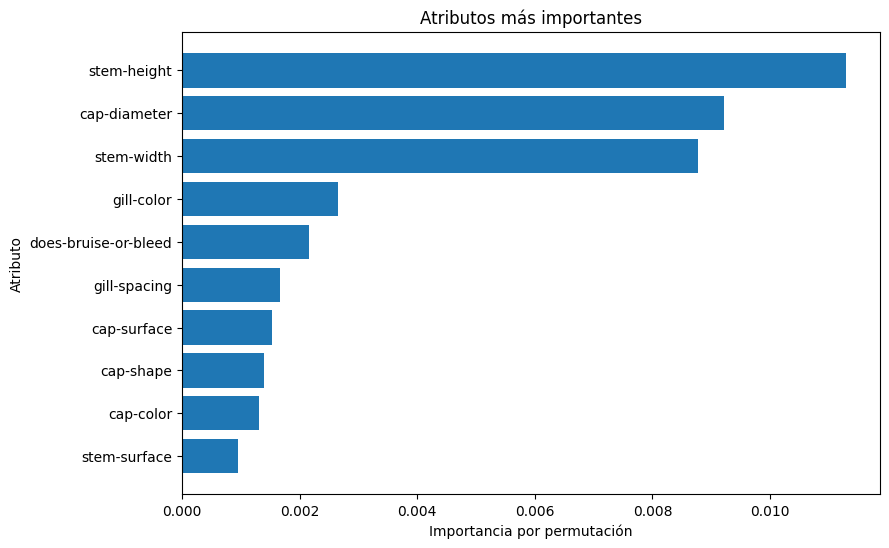

In [ ]:
# Graficar los diez atributos más importantes
top_atributos = tabla_importancia.head(10).sort_values(
    by='Importancia'
)

plt.figure(figsize=(9, 6))
plt.barh(
    top_atributos['Atributo'],
    top_atributos['Importancia']
)
plt.title("Atributos más importantes")
plt.xlabel("Importancia por permutación")
plt.ylabel("Atributo")
plt.show()


####**3.7 Mejor modelo sin el atributo clave **

Se elimina el atributo más importante y se vuelve a entrenar el mejor modelo.  
Después se comparan las métricas, especialmente el recall de la clase venenosa.


In [ ]:
# Eliminar el atributo clave
X_train_sin_atributo = X_train.drop(columns=[atributo_clave])
X_val_sin_atributo = X_val.drop(columns=[atributo_clave])

# Identificar nuevamente las columnas categóricas y numéricas
categorical_cols_sin = X_train_sin_atributo.select_dtypes(
    include=['object', 'category']
).columns.tolist()

numerical_cols_sin = X_train_sin_atributo.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

# Crear un nuevo transformador sin el atributo eliminado
preprocessor_sin_atributo = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_cols_sin
        ),
        (
            'num',
            StandardScaler(),
            numerical_cols_sin
        )
    ],
    remainder='passthrough'
)

# Construir el pipeline con el mismo mejor modelo
modelo_sin_atributo = Pipeline(steps=[
    ('preprocesador', preprocessor_sin_atributo),
    ('modelo', clone(mejor_modelo))
])

# Entrenar nuevamente sin el atributo clave
modelo_sin_atributo.fit(
    X_train_sin_atributo,
    y_train
)

# Realizar predicciones
pred_sin_atributo = modelo_sin_atributo.predict(
    X_val_sin_atributo
)


In [ ]:
# Predicciones del mejor modelo con todos los atributos
pred_modelo_original = pipeline_mejor_modelo.predict(X_val)

# Métricas del modelo original
metricas_original = {
    'Accuracy': accuracy_score(y_val, pred_modelo_original),
    'Precision venenoso': precision_score(
        y_val,
        pred_modelo_original,
        pos_label='p',
        zero_division=0
    ),
    'Recall venenoso': recall_score(
        y_val,
        pred_modelo_original,
        pos_label='p',
        zero_division=0
    ),
    'F1 venenoso': f1_score(
        y_val,
        pred_modelo_original,
        pos_label='p',
        zero_division=0
    )
}

# Métricas del modelo sin el atributo clave
metricas_sin_atributo = {
    'Accuracy': accuracy_score(y_val, pred_sin_atributo),
    'Precision venenoso': precision_score(
        y_val,
        pred_sin_atributo,
        pos_label='p',
        zero_division=0
    ),
    'Recall venenoso': recall_score(
        y_val,
        pred_sin_atributo,
        pos_label='p',
        zero_division=0
    ),
    'F1 venenoso': f1_score(
        y_val,
        pred_sin_atributo,
        pos_label='p',
        zero_division=0
    )
}

# Comparar ambos resultados
comparacion_atributo = pd.DataFrame(
    [metricas_original, metricas_sin_atributo],
    index=[
        f'Con {atributo_clave}',
        f'Sin {atributo_clave}'
    ]
)

display(comparacion_atributo.round(4))


,Accuracy,Precision venenoso,Recall venenoso,F1 venenoso
Con stem-height,1.0,1.0,1.0,1.0
Sin stem-height,1.0,1.0,1.0,1.0


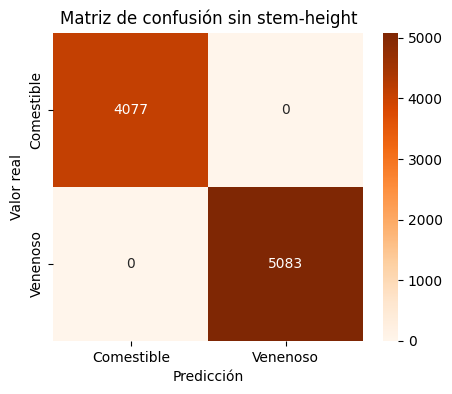

In [ ]:
# Matriz de confusión del modelo sin el atributo clave
matriz_sin_atributo = confusion_matrix(
    y_val,
    pred_sin_atributo,
    labels=['e', 'p']
)

plt.figure(figsize=(5, 4))
sns.heatmap(
    matriz_sin_atributo,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Comestible', 'Venenoso'],
    yticklabels=['Comestible', 'Venenoso']
)
plt.title(f"Matriz de confusión sin {atributo_clave}")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()


In [ ]:
# Mostrar el cambio en el recall de la clase venenosa
recall_original = metricas_original['Recall venenoso']
recall_sin_atributo = metricas_sin_atributo['Recall venenoso']

print(f"Recall original: {recall_original:.4f}")
print(f"Recall sin {atributo_clave}: {recall_sin_atributo:.4f}")
print(
    f"Diferencia: "
    f"{recall_sin_atributo - recall_original:.4f}"
)


Recall original: 1.0000
Recall sin stem-height: 1.0000
Diferencia: 0.0000


####**Análisis de la Fase 3**

La tabla comparativa permite identificar cuál de los cuatro modelos obtuvo el mejor resultado en validación. Para elegirlo se utilizó principalmente el F1 de la clase venenosa, ya que combina precision y recall.

Después se identificó el atributo más importante y se repitió el entrenamiento sin esa variable. La comparación permite observar cuánto dependía el modelo de ese atributo y si disminuyó su capacidad para detectar hongos venenosos.

El conjunto de prueba no se utilizó en esta fase y se mantiene reservado para la evaluación final.

**Fase 4 — Aprendizaje no supervisado**

* Aplicar K-medias sobre los datos codificados: usar el método del codo o silhouette
para elegir k, y comparar los clusters obtenidos contra las etiquetas reales (tabla
cruzada cluster vs. clase). ¿Los grupos "descubren" la separación
comestible/venenoso?
* Aplicar DBSCAN y comparar: ¿cuántos clusters encuentra? ¿qué puntos marca
como ruido? Discutan por qué los resultados difieren de K-medias.
* Visualización 2D de los clusters (pueden usar PCA para reducir dimensiones antes
de graficar).

#**Fase 4**

### 1. Importación de Librerías y Preprocesamiento
En esta sección importamos las herramientas necesarias, separamos nuestra variable objetivo (`class`) de las características, imputamos los valores nulos utilizando la moda (debido a la naturaleza categórica de los datos) y transformamos los datos a un formato numérico escalado, lo cual es vital para los algoritmos basados en distancias.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

# Separar variables
y_real = df['class']
X = df.drop('class', axis=1)

# Imputación de nulos (Sintaxis actualizada para evitar el FutureWarning)
for col in X.columns:
    if X[col].isnull().sum() > 0:
        X[col] = X[col].fillna(X[col].mode()[0])

# Codificación de variables categóricas a numéricas
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Escalamiento de los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Preprocesamiento completado. Forma de los datos escalados:", X_scaled.shape)

Preprocesamiento completado. Forma de los datos escalados: (61069, 20)


### 2. Selección de K: Método del Codo
Para determinar el número óptimo de clústeres para K-Means, iteramos sobre diferentes valores de K y calculamos la inercia (la suma de las distancias al cuadrado de las muestras a su centroide más cercano).

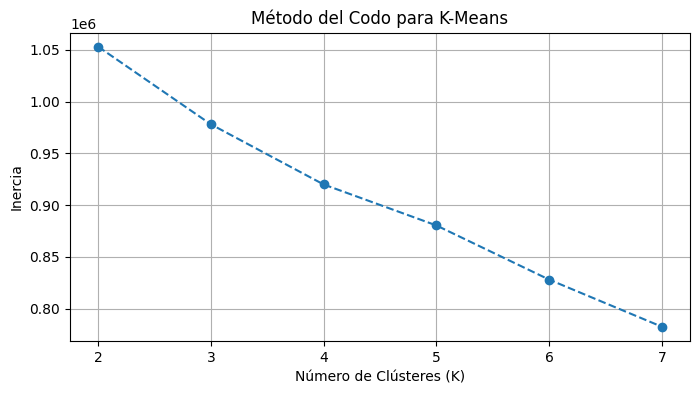

In [ ]:
inertia = []
K_range = range(2, 8)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Método del Codo para K-Means')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Inercia')
plt.grid(True)
plt.show()

### 3. Modelo K-Means
Basándonos en la naturaleza binaria del problema original (hongos comestibles vs venenosos), aplicamos el algoritmo K-Means con $K=2$ y contrastamos los clústeres generados contra las etiquetas reales para evaluar la correspondencia.

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_kmeans = kmeans.fit_predict(X_scaled)

print("--- Tabla Cruzada: K-Means vs Clase Real ---")
crosstab_kmeans = pd.crosstab(clusters_kmeans, y_real, rownames=['Clúster K-Means'], colnames=['Clase Real'])
print(crosstab_kmeans)

--- Tabla Cruzada: K-Means vs Clase Real ---
Clase Real           e      p
Clúster K-Means              
0                10098  11644
1                17083  22244


### 4. Modelo DBSCAN
A diferencia de K-Means, DBSCAN agrupa por densidad. Configuramos los parámetros `eps=2.0` y `min_samples=20` para intentar capturar la densidad de los datos categóricos codificados y detectar posibles anomalías (ruido).

In [ ]:
dbscan = DBSCAN(eps=2.0, min_samples=20)
clusters_dbscan = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_noise_db = list(clusters_dbscan).count(-1)
print(f"DBSCAN encontró {n_clusters_db} clústeres y {n_noise_db} puntos de ruido.")

print("\n--- Tabla Cruzada: DBSCAN vs Clase Real (Muestra) ---")
crosstab_dbscan = pd.crosstab(clusters_dbscan, y_real, rownames=['Clúster DBSCAN'], colnames=['Clase Real'])
print(crosstab_dbscan.head(15)) # Limitado a 15 para no saturar la pantalla

DBSCAN encontró 93 clústeres y 326 puntos de ruido.

--- Tabla Cruzada: DBSCAN vs Clase Real (Muestra) ---
Clase Real          e      p
Clúster DBSCAN              
-1                 79    247
 0                  0    177
 1                  0    176
 2                  0    353
 3                931   1971
 4                529    706
 5                  0    165
 6                  0    188
 7                527      0
 8                  0    197
 9              13932  14274
 10               182      0
 11               171      0
 12               177      0
 13               195    179


### 5. Reducción de Dimensionalidad (PCA) y Visualización
Dado que el dataset tiene múltiples características, utilizamos el Análisis de Componentes Principales (PCA) para reducir la dimensionalidad a 2 componentes. Esto nos permite visualizar gráficamente cómo K-Means agrupó los datos en comparación con las clases reales.

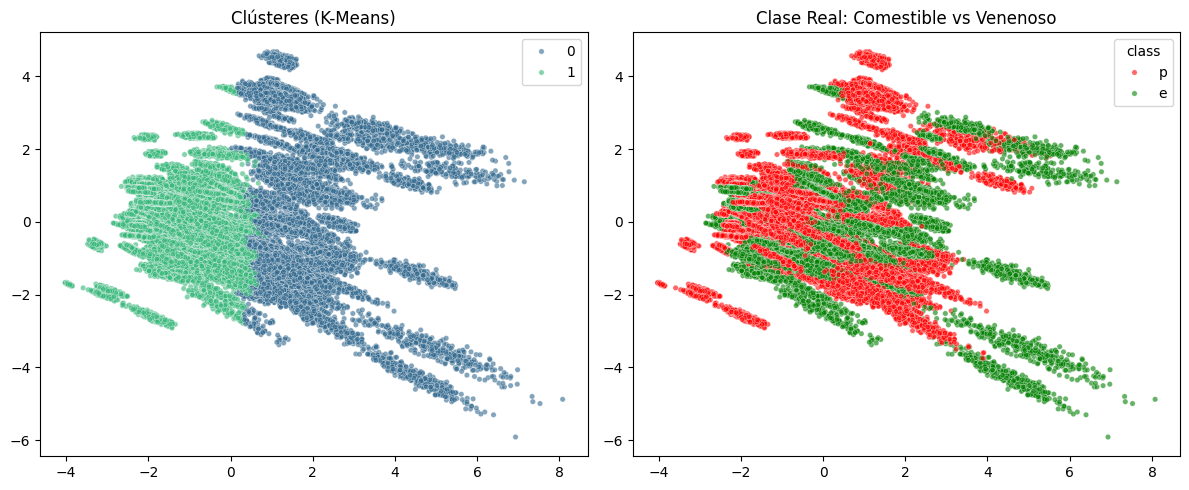

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 5))

# Gráfico K-Means
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters_kmeans, palette='viridis', s=15, alpha=0.6)
plt.title('Clústeres (K-Means)')

# Gráfico Clase Real
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_real, palette={'e': 'green', 'p': 'red'}, s=15, alpha=0.6)
plt.title('Clase Real: Comestible vs Venenoso')

plt.tight_layout()
plt.show()

### Análisis y Discusión Final de los Resultados

* **Selección de K en K-Means:** Aunque el gráfico del Método del Codo muestra una disminución gradual típica en datos de alta dimensionalidad, se seleccionó $K=2$. La justificación metodológica de esta elección es determinar si un modelo de aprendizaje no supervisado es capaz de encontrar por sí solo la separación natural más importante del dataset: hongos comestibles (`e`) y venenosos (`p`).
* **Rendimiento de K-Means vs Clase Real:** La tabla cruzada revela que K-Means no logra aislar la toxicidad de manera perfecta. Hay presencia de ambas clases (comestibles y venenosos) en los dos clústeres. El modelo divide los datos geométricamente, pero las variables no forman grupos globulares puros basados en la distancia euclidiana respecto al veneno.
* **Comportamiento de DBSCAN:** A diferencia de K-Means, DBSCAN encuentra decenas de micro-clústeres (93) y aísla 326 puntos como ruido. Esto ocurre porque DBSCAN evalúa densidad. Al ser datos categóricos transformados numéricamente (como formas de sombreros, olores o colores), los registros forman "bloques" hiperdensos en el espacio dimensional, lo que lleva a DBSCAN a identificar estos bloques compactos como clústeres individuales, logrando en muchos casos subgrupos 100% puros (o todos venenosos o todos comestibles).

#**Fase 5** Predicciones y pruebas propias


In [ ]:
#Evaluación del modelo final sobre el conjunto de prueba (ÚNICA VEZ)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Entrenar nuevamente con entrenamiento
pipeline_mejor_modelo.fit(X_train, y_train)

# Predicción sobre el conjunto de prueba
y_pred_test = pipeline_mejor_modelo.predict(X_test)

print("========== RESULTADOS FINALES ==========\n")

print(classification_report(y_test, y_pred_test))

print(f"Accuracy : {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision: {precision_score(y_test,y_pred_test,pos_label='p'):.4f}")
print(f"Recall   : {recall_score(y_test,y_pred_test,pos_label='p'):.4f}")
print(f"F1 Score : {f1_score(y_test,y_pred_test,pos_label='p'):.4f}")

========== RESULTADOS FINALES ==========

              precision    recall  f1-score   support

           e       1.00      1.00      1.00      4077
           p       1.00      1.00      1.00      5084

    accuracy                           1.00      9161
   macro avg       1.00      1.00      1.00      9161
weighted avg       1.00      1.00      1.00      9161

Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000


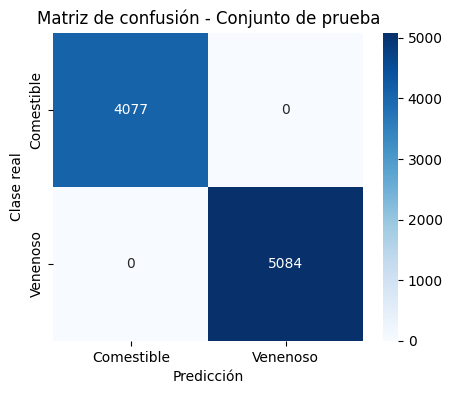

In [ ]:
#matriz de confusión del conjunto de prueba
cm = confusion_matrix(
    y_test,
    y_pred_test,
    labels=['e','p']
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Comestible","Venenoso"],
    yticklabels=["Comestible","Venenoso"]
)

plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.title("Matriz de confusión - Conjunto de prueba")

plt.show()

In [ ]:
#creacion de 5 hongos inventados
hongos_nuevos = pd.DataFrame([

    # Hongo 1: Grande, colores llamativos y tallo grueso.
    # Esperado: Venenoso (p)
    {
        'cap-diameter': 18.5,
        'cap-shape': 'x',
        'cap-surface': 'g',
        'cap-color': 'e',
        'does-bruise-or-bleed': 't',
        'gill-attachment': 'e',
        'gill-spacing': 'c',
        'gill-color': 'w',
        'stem-height': 15.0,
        'stem-width': 20.0,
        'stem-root': 'b',
        'stem-surface': 's',
        'stem-color': 'w',
        'veil-type': 'u',
        'veil-color': 'w',
        'has-ring': 't',
        'ring-type': 'p',
        'spore-print-color': 'k',
        'habitat': 'd',
        'season': 'w'
    },

    # Hongo 2: Pequeño, colores claros, tallo delgado.
    # Esperado: Comestible (e)
    {
        'cap-diameter': 4.2,
        'cap-shape': 'f',
        'cap-surface': 's',
        'cap-color': 'y',
        'does-bruise-or-bleed': 'f',
        'gill-attachment': 'a',
        'gill-spacing': 'd',
        'gill-color': 'w',
        'stem-height': 5.3,
        'stem-width': 4.8,
        'stem-root': 'e',
        'stem-surface': 'y',
        'stem-color': 'w',
        'veil-type': 'u',
        'veil-color': 'w',
        'has-ring': 'f',
        'ring-type': 'f',
        'spore-print-color': 'w',
        'habitat': 'g',
        'season': 's'
    },

    # Hongo 3: Tamaño mediano con características mixtas.
    # Esperado: Difícil de clasificar.
    {
        'cap-diameter': 9.0,
        'cap-shape': 'c',
        'cap-surface': 'h',
        'cap-color': 'o',
        'does-bruise-or-bleed': 't',
        'gill-attachment': 'x',
        'gill-spacing': 'c',
        'gill-color': 'y',
        'stem-height': 8.5,
        'stem-width': 10.0,
        'stem-root': 's',
        'stem-surface': 'g',
        'stem-color': 'y',
        'veil-type': 'u',
        'veil-color': 'w',
        'has-ring': 't',
        'ring-type': 'g',
        'spore-print-color': 'n',
        'habitat': 'm',
        'season': 'a'
    },

    # Hongo 4: Muy grande y robusto.
    # Esperado: Venenoso (p)
    {
        'cap-diameter': 25.0,
        'cap-shape': 'p',
        'cap-surface': 'w',
        'cap-color': 'k',
        'does-bruise-or-bleed': 't',
        'gill-attachment': 'e',
        'gill-spacing': 'c',
        'gill-color': 'k',
        'stem-height': 22.0,
        'stem-width': 32.0,
        'stem-root': 'b',
        'stem-surface': 'w',
        'stem-color': 'k',
        'veil-type': 'u',
        'veil-color': 'k',
        'has-ring': 't',
        'ring-type': 'l',
        'spore-print-color': 'k',
        'habitat': 'd',
        'season': 'u'
    },

    # Hongo 5: Mediano, colores poco llamativos y tallo fino.
    # Esperado: Comestible (e)
    {
        'cap-diameter': 6.3,
        'cap-shape': 'x',
        'cap-surface': 'i',
        'cap-color': 'w',
        'does-bruise-or-bleed': 'f',
        'gill-attachment': 'a',
        'gill-spacing': 'd',
        'gill-color': 'w',
        'stem-height': 6.5,
        'stem-width': 5.5,
        'stem-root': 'e',
        'stem-surface': 's',
        'stem-color': 'w',
        'veil-type': 'u',
        'veil-color': 'w',
        'has-ring': 'f',
        'ring-type': 'f',
        'spore-print-color': 'w',
        'habitat': 'g',
        'season': 'u'
    }

])

In [ ]:
predicciones = pipeline_mejor_modelo.predict(hongos_nuevos)

hongos_nuevos["Predicción"] = predicciones

hongos_nuevos["Predicción"] = hongos_nuevos["Predicción"].map({
    "e":"Comestible",
    "p":"Venenoso"
})

hongos_nuevos

,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,...,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season,Predicción
0,18.5,x,g,e,t,e,c,w,15.0,20.0,...,s,w,u,w,t,p,k,d,w,Venenoso
1,4.2,f,s,y,f,a,d,w,5.3,4.8,...,y,w,u,w,f,f,w,g,s,Comestible
2,9.0,c,h,o,t,x,c,y,8.5,10.0,...,g,y,u,w,t,g,n,m,a,Comestible
3,25.0,p,w,k,t,e,c,k,22.0,32.0,...,w,k,u,k,t,l,k,d,u,Comestible
4,6.3,x,i,w,f,a,d,w,6.5,5.5,...,s,w,u,w,f,f,w,g,u,Venenoso


Los hongos 1 y 2 los clasifico correctamente. Mientras que el 3 al tener informacion ambigua lo clasico como comestible, esto sugiere que las características específicas (como la gill-color 'y' o stem-color 'y') o la combinación de ellas llevaron a esta clasificación. el hongo 4 a pesar de su tamaño lo clasifico como comestible. el hongo 5 lo clasifico como venenoso, aunque es mediano y de colores poco llamativos lo que podria sugerir comestible.

En general, las predicciones son parcialmente coherentes con el EDA. en los casos extremos (Hongo 1 y 2) se alinearon bien, pero en los casos más ambiguos o con combinaciones atípicas (Hongo 3, 4 y 5) revelan la complejidad del modelo y la posibilidad de que ciertas características dominen sobre otras que parecían importantes en el análisis exploratorio simple.

In [ ]:
#tres ejemplos mal clasificados
errores = X_test.copy()

errores["Real"] = y_test.values

errores["Predicción"] = y_pred_test

mal = errores[
    errores["Real"] != errores["Predicción"]
]

mal.head(3)

,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,...,stem-surface,stem-color,veil-color,has-ring,ring-type,spore-print-color,habitat,season,Real,Predicción


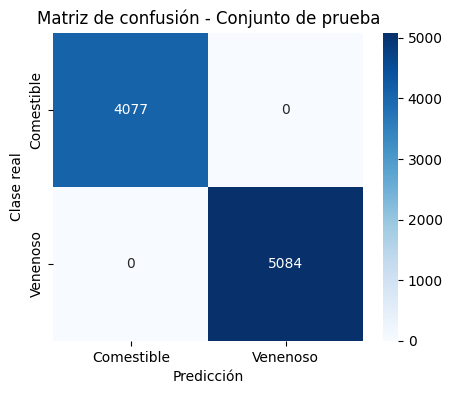

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred_test,
    labels=['e','p']
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Comestible","Venenoso"],
    yticklabels=["Comestible","Venenoso"]
)

plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.title("Matriz de confusión - Conjunto de prueba")

plt.show()

No se encontraron ejemplos mal clasificados.debido a que el mejor modelo kNN ha logrado una precisión, recall y F1-score del 100% en el conjunto de prueba. lo que hace que en este escenario, el modelo no ha cometido ningún error en este conjunto de datos específico, por lo que no es posible analizar por qué falló, ya que no hubo fallos.

### **Conclusión sobre el Error más Peligroso**
Los errores mas peligrosos en este tipo de clasificaciones es el modelo de falsos negativos, es decir que el modelo diga que un hongo es comestible cuando en realidad es venenoso. y este tipo de errores en la vida real puede ser fatal.

Nuestro mejor modelo no clasificó ningún hongo venenoso como comestible en el conjunto de prueba. El recall del 100% para la clase venenosa nos da un buen resultado y es lo deseable en este tipo de contextos.

**¿Aceptarían ese riesgo en la vida real?**

Aunque pareciera que el modelo no se equivoco en nada y dio resultados. la verdad es que en situaciones de la vida real no se puede confiar en un modelo asi de simple, por lo que no aceptaria ese riesgo. se necesitaria validar mucho mas a fondo el modelo, con muchos mas datos que aporten diversidad, para verificar su eficacia. al final esta solo es una practica sobre un conjunto de prueba, por lo que lo mas seguro es que no sea adecuado para la vida real.